# Capstone Project 01 — The Malaria Detector — Worked Solution

*One possible answer — not the answer.*

> **STOP — have you attempted it yourself first?** This notebook is the worked solution to the
> project brief in [README.md](README.md). Try each stage in your own fresh notebook before
> reading on: you will learn far more from your own dead ends than from mine. Come back stage
> by stage to compare — choices, not just numbers.

The data behind this project is real. Researchers at the U.S. National Institutes of Health
photographed Giemsa-stained thin blood-smear slides from patients at Chittagong Medical College
Hospital in Bangladesh, used software to cut each slide photo into pictures of individual red
blood cells, and had expert readers label every cell: parasitized with *Plasmodium*, or
uninfected. The result is 27,558 single-cell photos, half infected and half healthy.

Why it matters: microscopy of exactly these smears is still the gold-standard malaria
diagnostic, but it requires a trained microscopist per slide — the scarcest resource in the
rural clinics that carry most of the malaria burden. A classifier that pre-screens cells and
flags the suspicious ones for human review is the kind of tool that could stretch one expert
across many clinics. In this notebook we build that classifier end to end, and — just as
important — evaluate it the way a diagnostic test is evaluated.

In [1]:
import numpy as np                          # arrays (Module 01)
import pandas as pd                         # tables (Module 02)
import matplotlib.pyplot as plt             # plots (every module)
import seaborn as sns                       # nicer plots (Module 02)
import torch                                # tensors + autograd (Module 10)
import torch.nn as nn                       # neural-network building blocks (Modules 10-11)
from datasets import load_dataset           # HuggingFace downloader (Module 01)

# scikit-learn pieces, all old friends:
from sklearn.model_selection import train_test_split   # honest splits (Modules 04, 07)
from sklearn.preprocessing import StandardScaler       # feature scaling (Modules 04, 07)
from sklearn.linear_model import LogisticRegression    # the baseline (Module 06)
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score  # diagnostics (Module 06)

sns.set_theme(style="whitegrid", palette="colorblind")

# Fix every source of randomness so re-running gives the same numbers (and so
# your attempt, if you used the same seeds, is directly comparable).
np.random.seed(42)       # numpy's random generator
torch.manual_seed(42)    # pytorch's random generator (weight init, batch shuffling)

## 1. Look at the data (Modules 02–04)

The first-look ritual from Module 02, adapted from tables to images: how much data, what does
one row look like, is anything missing or odd — and, because these are photos, *actually look
at them with your own eyes* before any code models anything.

In [2]:
# The dataset is already cached locally, so this loads in seconds.
cells = load_dataset("dpdl-benchmark/malaria", split="train")

print(cells)              # how many rows, which columns
print(cells.features)     # the column types

# One row is a dictionary with two entries: 'image' and 'label'.
example = cells[0]
print(type(example["image"]))     # a PIL Image object -- a photo held in memory
print(example["image"].size)      # (width, height) in pixels
print(example["label"])           # an integer... but WHICH class is which? See below.

Dataset({
    features: ['image', 'label'],
    num_rows: 27558
})
{'image': Image(mode=None, decode=True), 'label': Value('int64')}
<class 'PIL.PngImagePlugin.PngImageFile'>
(103, 103)
1


In [3]:
# Class balance: how many cells of each label?
labels_raw = np.array(cells["label"])     # all 27,558 labels as one NumPy array

# np.bincount counts how many times each value appears: position 0 holds the
# number of 0s, position 1 the number of 1s (Module 01).
counts = np.bincount(labels_raw)
print("cells with label 0:", counts[0])
print("cells with label 1:", counts[1])
# Perfectly balanced -- 13,779 of each. Rare luxury in real data.

cells with label 0: 13779
cells with label 1: 13779


### The label detective problem

The `label` column is a bare integer, and the dataset card never says which number means
parasitized. **Never guess at something you can check.** We're biologists: Giemsa stain binds
parasite chromatin and stains *Plasmodium* dark purple, while a healthy red blood cell —
which has no nucleus at all — should be smooth, uniform cytoplasm. So put photos of each
label side by side and read the answer off the cells themselves.

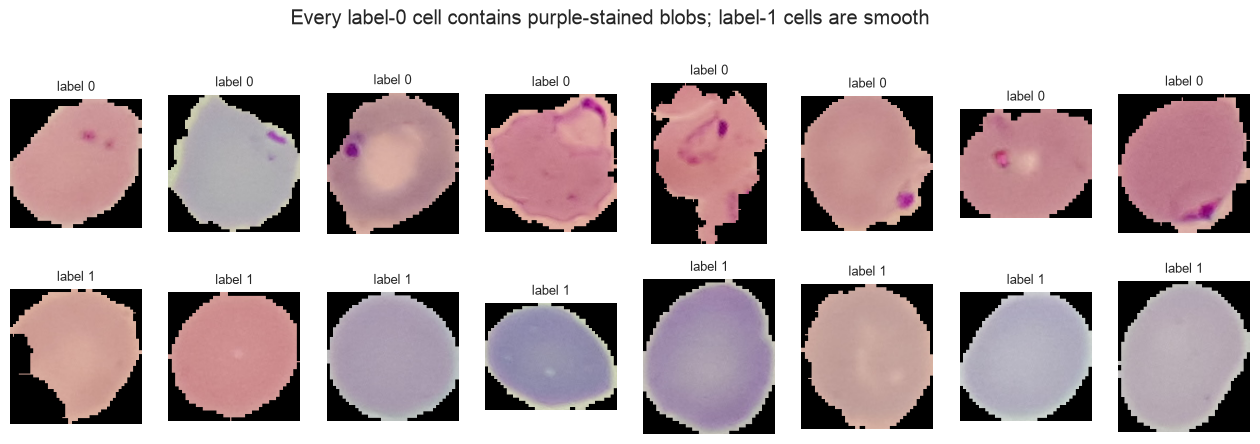

In [4]:
# Collect the row numbers of each label.
# np.where(condition)[0] returns the positions where the condition is True (Module 01).
rows_label0 = np.where(labels_raw == 0)[0]
rows_label1 = np.where(labels_raw == 1)[0]

# Pick 8 random examples of each (reproducible, because we seeded numpy above).
picks0 = np.random.choice(rows_label0, size=8, replace=False)
picks1 = np.random.choice(rows_label1, size=8, replace=False)

fig, axes = plt.subplots(2, 8, figsize=(16, 4.6))
for col in range(8):
    row0 = int(picks0[col])            # int() because dataset indexing wants a plain integer
    row1 = int(picks1[col])
    axes[0, col].imshow(cells[row0]["image"])
    axes[0, col].set_title("label 0", fontsize=9)
    axes[1, col].imshow(cells[row1]["image"])
    axes[1, col].set_title("label 1", fontsize=9)
# axes.flat walks through all 16 panels one by one, top row first.
for panel in axes.flat:
    panel.axis("off")                  # photos don't need axis ticks
fig.suptitle("Every label-0 cell contains purple-stained blobs; label-1 cells are smooth", y=1.04)
plt.show()

**The verdict, with evidence.** Every label-0 cell above contains at least one dark-purple
inclusion — exactly what Giemsa-stained *Plasmodium* looks like (often a "ring form": a dot of
chromatin with a wisp of cytoplasm). Every label-1 cell is smooth, anucleate cytoplasm, as a
healthy red blood cell should be. Conclusion: **label 0 = parasitized, label 1 = uninfected.**
(Run the cell again with different random picks if you want more evidence — it holds.)

One more convention before modeling. In medicine, a "positive" test result means *disease
present*, and sensitivity/specificity (Module 06) are defined around that convention. So we
recode: **y = 1 means parasitized**, y = 0 means uninfected.

In [5]:
# Recode so that 1 = parasitized (disease present = "positive"), 0 = uninfected.
y_all = np.zeros(len(labels_raw), dtype=np.int64)   # start with all zeros
y_all[labels_raw == 0] = 1     # rows whose raw label is 0 (parasitized) become y = 1

print("parasitized (y=1):", int(np.sum(y_all == 1)))
print("uninfected  (y=0):", int(np.sum(y_all == 0)))

parasitized (y=1): 13779
uninfected  (y=0): 13779


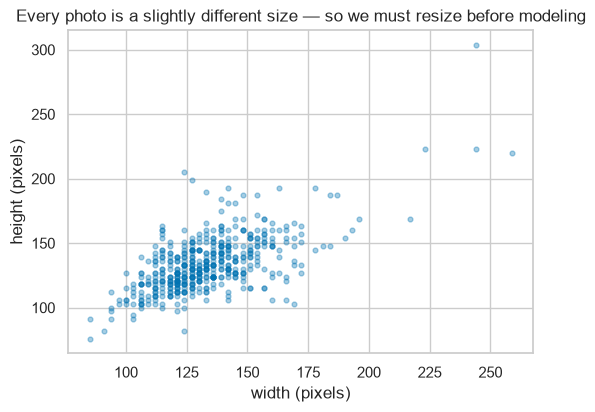

width range:  85 to 259 pixels
height range: 76 to 304 pixels


In [6]:
# Last first-look question: are all the photos the same size? Check 500 random cells.
sample_rows = np.random.choice(len(cells), size=500, replace=False)
widths = []
heights = []
for row in sample_rows:
    photo = cells[int(row)]["image"]
    widths.append(photo.size[0])      # .size on a PIL image is (width, height)
    heights.append(photo.size[1])

fig, ax = plt.subplots(figsize=(6, 4.2))
ax.scatter(widths, heights, s=12, alpha=0.35)
ax.set_xlabel("width (pixels)")
ax.set_ylabel("height (pixels)")
ax.set_title("Every photo is a slightly different size — so we must resize before modeling")
plt.show()

print("width range: ", min(widths), "to", max(widths), "pixels")
print("height range:", min(heights), "to", max(heights), "pixels")

Sizes vary because each photo is cropped to its cell. Models want every input the same
shape, so we'll resize: **64×64** for the CNN, **32×32** for the baseline.

## 2. An honest protocol (Module 07)

Now — *before* any model exists to tempt us — we lock in the experimental design, exactly like
deciding your controls before running the experiment:

- Subsample **8,500** of the 27,558 images so everything trains in minutes on a laptop
  (a GPU would happily use all of it; see the comment in the CNN section for what that buys).
- Split into **6,000 train / 1,000 validation / 1,500 test**, *stratified* — meaning each split
  keeps the 50/50 class balance.
- The **training set** teaches the models. The **validation set** answers every question we ask
  along the way (is it learning? which threshold?). The **test set** is opened **exactly once**,
  in Stage 5, to report final numbers. Peeking earlier would make the final numbers as
  meaningless as reading your positive control after adjusting the gel photo.

In [7]:
all_indices = np.arange(len(cells))     # the row numbers 0, 1, ..., 27557

# Step 1: pull a laptop-sized subset of 8,500 rows.
# stratify=y_all makes train_test_split keep the 50/50 class balance in both pieces.
subset_idx, leftover_idx, subset_y, leftover_y = train_test_split(
    all_indices, y_all, train_size=8500, stratify=y_all, random_state=42)

# Step 2: 6,000 of those become the training set; 2,500 remain.
train_idx, temp_idx, y_train, y_temp = train_test_split(
    subset_idx, subset_y, train_size=6000, stratify=subset_y, random_state=42)

# Step 3: the remaining 2,500 become 1,000 validation + 1,500 test.
val_idx, test_idx, y_val, y_test = train_test_split(
    temp_idx, y_temp, train_size=1000, stratify=y_temp, random_state=42)

# Proof the stratification worked: each split should be ~50% parasitized.
print("train:", len(train_idx), "cells -- parasitized fraction:", round(float(np.mean(y_train)), 3))
print("val:  ", len(val_idx), "cells -- parasitized fraction:", round(float(np.mean(y_val)), 3))
print("test: ", len(test_idx), "cells -- parasitized fraction:", round(float(np.mean(y_test)), 3))

train: 6000 cells -- parasitized fraction: 0.5
val:   1000 cells -- parasitized fraction: 0.5
test:  1500 cells -- parasitized fraction: 0.5


In [8]:
def load_images(indices, size):
    # Build one big array of shape (how_many, size, size, 3) -- 3 for red/green/blue.
    # dtype=np.uint8 stores each color value as a whole number 0-255 (compact in memory).
    images = np.zeros((len(indices), size, size, 3), dtype=np.uint8)
    for i in range(len(indices)):
        row = int(indices[i])
        photo = cells[row]["image"]
        small = photo.resize((size, size))    # shrink the photo to size x size pixels
        images[i] = np.array(small)           # PIL image -> NumPy array of pixel values
    return images

# 64x64 color versions for the CNN (Stage 4)...
X_train_64 = load_images(train_idx, 64)
X_val_64 = load_images(val_idx, 64)
X_test_64 = load_images(test_idx, 64)

# ...and 32x32 versions for the simple baseline (Stage 3).
X_train_32 = load_images(train_idx, 32)
X_val_32 = load_images(val_idx, 32)
X_test_32 = load_images(test_idx, 32)

print("CNN training images:     ", X_train_64.shape)   # (6000, 64, 64, 3)
print("baseline training images:", X_train_32.shape)   # (6000, 32, 32, 3)

CNN training images:      (6000, 64, 64, 3)
baseline training images: (6000, 32, 32, 3)


## 3. Baseline first (Modules 06–07)

Before a neural network earns its complexity, run the control experiment: *would a simple rule
do?* Our simple rule is Module 06's logistic regression, fed nothing but raw pixels — each
32×32 color image flattened into one long row of 32 × 32 × 3 = 3,072 numbers, one column per
pixel-and-color position. If this scores well, we don't need deep learning; if the CNN can't
beat it, the CNN isn't earning its keep. Either way, the baseline is what makes the CNN's
number *mean* something.

In [9]:
# Flatten: each image becomes one row of 3,072 numbers.
# reshape is from Module 01; the -1 means 'work out this dimension for me'.
Xb_train = X_train_32.reshape(len(X_train_32), -1).astype(np.float32)
Xb_val = X_val_32.reshape(len(X_val_32), -1).astype(np.float32)
Xb_test = X_test_32.reshape(len(X_test_32), -1).astype(np.float32)

# Scale every pixel column to mean 0, spread 1. The scaler is FIT on training
# data only, then applied unchanged to val/test -- the no-leakage rule from Module 07.
scaler = StandardScaler()
Xb_train = scaler.fit_transform(Xb_train)
Xb_val = scaler.transform(Xb_val)
Xb_test = scaler.transform(Xb_test)

# max_iter is raised because 3,072 columns need more steps than sklearn's default
# allows before the fit settles.
baseline = LogisticRegression(max_iter=4000, random_state=42)
baseline.fit(Xb_train, y_train)

print("baseline accuracy on train:", round(baseline.score(Xb_train, y_train), 3))
print("baseline accuracy on val:  ", round(baseline.score(Xb_val, y_val), 3))

baseline accuracy on train: 0.882
baseline accuracy on val:   0.671


**Reading the baseline.** About 88% on the training set but only ~67% on validation. Two lessons in one pair of numbers:

1. The gap says the model partly **memorized** its training pixels (Module 05's overfitting, back again).
2. The ~67% ceiling is **structural, not bad luck**. Logistic regression owns one weight per pixel position — "purple at position (12, 20) means infected". But the parasite can sit *anywhere* in the cell, so evidence learned at one position doesn't transfer to any other. (We also tried grayscale, stronger regularization, and per-image normalization while writing this solution: everything plateaus in the mid-to-high 60s.)

So the bar the CNN must clear is **67%**, not the 50% coin flip — and the *reason* the baseline stalls tells us exactly which tool to reach for next.

## 4. The CNN (Modules 10–11)

Convolution is built for exactly the problem that capped the baseline: a small filter slides
across the *whole* image detecting its motif **wherever it occurs** — Module 11's restriction
enzyme, scanning any genome for its one recognition site. We reuse Module 11's recipe (conv →
pool, three times, then dense layers), with one twist: a **single output** passed through a
sigmoid to give P(parasitized). The network literally ends in Module 06's logistic regression —
it just gets to *learn* its input features instead of being handed raw pixels.

In [10]:
def to_tensor(images):
    # 1) uint8 values 0-255 -> float32 values 0.0-1.0 (networks train better on small inputs)
    scaled = images.astype(np.float32) / 255.0
    t = torch.from_numpy(scaled)         # NumPy array -> PyTorch tensor (Module 10)
    # 2) PyTorch convolutions want the color channel FIRST: (n, 3, 64, 64), not (n, 64, 64, 3).
    #    permute reorders the dimensions: keep dim 0, then move dim 3 up, then dims 1 and 2.
    t = t.permute(0, 3, 1, 2)
    return t

Xt_train = to_tensor(X_train_64)
Xt_val = to_tensor(X_val_64)
Xt_test = to_tensor(X_test_64)

# Labels as float32 tensors, because the binary-cross-entropy loss expects floats.
yt_train = torch.from_numpy(y_train.astype(np.float32))
yt_val = torch.from_numpy(y_val.astype(np.float32))

print("training tensor:", Xt_train.shape)   # (6000, 3, 64, 64)

training tensor: torch.Size([6000, 3, 64, 64])


In [11]:
class MalariaCNN(nn.Module):
    # Module 11's recipe: conv -> pool three times, then flatten into dense layers.
    def __init__(self):
        super().__init__()    # let PyTorch set up its nn.Module machinery first
        self.net = nn.Sequential(
            # 3 color channels in, 16 filters out; each filter is a 3x3 motif detector.
            # padding=1 keeps the image the same size after the convolution.
            nn.Conv2d(3, 16, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),                        # 64x64 -> 32x32
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),                        # 32x32 -> 16x16
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),                        # 16x16 -> 8x8
            nn.Flatten(),                           # 64 maps of 8x8 -> one row of 4,096
            nn.Linear(64 * 8 * 8, 64), nn.ReLU(),
            nn.Linear(64, 1),                       # ONE output: evidence of infection
        )

    def forward(self, x):
        # The output comes out with shape (batch, 1); .squeeze(1) drops that
        # trailing size-1 dimension so it lines up with the labels' shape (batch,).
        return self.net(x).squeeze(1)

model = MalariaCNN()

# Binary cross-entropy loss. 'WithLogits' means the sigmoid that turns the raw
# output into a probability is built into the loss (more numerically stable).
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)   # Adam, as in Modules 10-11

In [12]:
# Budget note: 6 epochs on 6,000 images trains in well under a minute on a laptop CPU.
# With the full 27,558 images and ~15 epochs (or a GPU via .to("mps"), Module 10),
# this same architecture reaches ~97-98% accuracy -- more data and more passes buy
# a few final points. We stop early and keep the whole notebook a few minutes long.
EPOCHS = 6
BATCH_SIZE = 64
n_train = len(Xt_train)

train_batch_losses = []   # loss after every batch, for the learning curve
val_losses = []           # validation loss at the end of each epoch
val_accuracies = []

for epoch in range(EPOCHS):
    model.train()                          # training mode
    epoch_loss_total = 0.0
    # torch.randperm gives a random ordering of 0..5999 -- a fresh shuffle each epoch.
    shuffled = torch.randperm(n_train)

    for start in range(0, n_train, BATCH_SIZE):        # step through in chunks of 64
        batch_rows = shuffled[start:start + BATCH_SIZE]
        x_batch = Xt_train[batch_rows]
        y_batch = yt_train[batch_rows]

        # The training-loop liturgy (Module 10): forward -> loss -> zero -> backward -> step.
        predictions = model(x_batch)
        loss = loss_fn(predictions, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_batch_losses.append(loss.item())          # .item() = 1-value tensor -> number
        epoch_loss_total += loss.item() * len(batch_rows)

    # End of epoch: how are we doing on cells the network never trains on?
    model.eval()                           # evaluation mode
    with torch.no_grad():                  # no gradients needed here -- faster
        val_logits = model(Xt_val)
        val_loss = loss_fn(val_logits, yt_val).item()
        val_probs = torch.sigmoid(val_logits)           # raw outputs -> probabilities
        val_predictions = (val_probs > 0.5).float()     # probability -> class call
        val_acc = float((val_predictions == yt_val).float().mean())

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    print("epoch", epoch + 1,
          "-- train loss:", round(epoch_loss_total / n_train, 4),
          "-- val loss:", round(val_loss, 4),
          "-- val accuracy:", round(val_acc, 4))

epoch 1 -- train loss: 0.6704 -- val loss: 0.5989 -- val accuracy: 0.677


epoch 2 -- train loss: 0.545 -- val loss: 0.4231 -- val accuracy: 0.845


epoch 3 -- train loss: 0.2891 -- val loss: 0.22 -- val accuracy: 0.926


epoch 4 -- train loss: 0.2014 -- val loss: 0.1903 -- val accuracy: 0.926


epoch 5 -- train loss: 0.1779 -- val loss: 0.1649 -- val accuracy: 0.941


epoch 6 -- train loss: 0.1732 -- val loss: 0.1744 -- val accuracy: 0.931


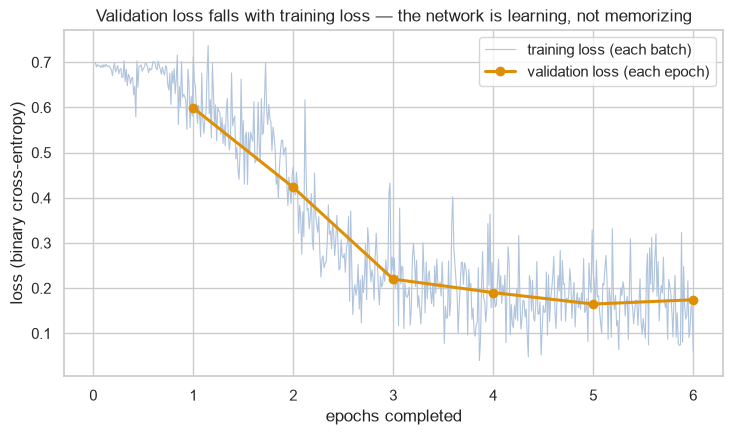

In [13]:
# The learning curve: every batch's training loss, plus validation loss per epoch.
n_batches = len(train_batch_losses)
batches_per_epoch = n_batches // EPOCHS               # // = whole-number division
# Convert 'batch number' into 'epochs completed' so both lines share an x-axis.
batch_x = np.arange(1, n_batches + 1) / batches_per_epoch
epoch_x = np.arange(1, EPOCHS + 1)

fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.plot(batch_x, train_batch_losses, color="lightsteelblue", linewidth=0.8,
        label="training loss (each batch)")
ax.plot(epoch_x, val_losses, color="#DE8F05", marker="o", linewidth=2.2,
        label="validation loss (each epoch)")
ax.set_xlabel("epochs completed")
ax.set_ylabel("loss (binary cross-entropy)")
ax.set_title("Validation loss falls with training loss — the network is learning, not memorizing")
ax.legend()
plt.show()

**Reading the curves.** Validation loss falls right alongside training loss for five epochs — the network is learning features that generalize, not memorizing cells — and validation accuracy climbs from 68% to ~93–94%. At epoch 6 the validation loss ticks up a hair while training loss keeps falling: the first whisper of memorization. If we trained much longer without more data, this is where Module 11's dropout (or data augmentation) would enter. We stop here.

## 5. Evaluate like a diagnostic (Module 06)

Now — and only now — we open the test set, once, for both models. A single accuracy number is
not enough for a medical tool, because the two errors are not the same mistake:

- **False positive** — a healthy cell flagged as infected. Cost: a human re-checks it. Minutes.
- **False negative** — an infected cell called healthy. Cost: an infected patient walks home
  untreated. This is the error a screening test must crush.

In [14]:
# --- The one and only visit to the test set. ---

# Baseline, on test:
baseline_test_predictions = baseline.predict(Xb_test)
baseline_test_acc = float(np.mean(baseline_test_predictions == y_test))

# CNN, on test:
model.eval()
with torch.no_grad():
    test_logits = model(Xt_test)
    test_probs = torch.sigmoid(test_logits).numpy()   # back to NumPy for sklearn's metrics

cnn_test_predictions = (test_probs > 0.5).astype(int)   # default threshold 0.5, for now
cnn_test_acc = float(np.mean(cnn_test_predictions == y_test))

print("baseline test accuracy:", round(baseline_test_acc, 3))
print("CNN test accuracy:     ", round(cnn_test_acc, 3))

baseline test accuracy: 0.663
CNN test accuracy:      0.942


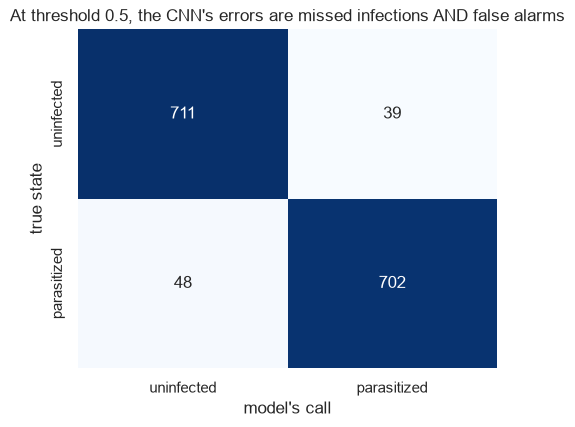

CNN sensitivity at 0.5: 0.936
CNN specificity at 0.5: 0.948
missed infections: 48 of 750


In [15]:
# The confusion matrix (Module 06): rows are the truth, columns are the model's call.
cm = confusion_matrix(y_test, cnn_test_predictions)

fig, ax = plt.subplots(figsize=(5.4, 4.4))
# annot=True writes the count inside each square; fmt='d' formats them as whole numbers.
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["uninfected", "parasitized"],
            yticklabels=["uninfected", "parasitized"], ax=ax)
ax.set_xlabel("model's call")
ax.set_ylabel("true state")
ax.set_title("At threshold 0.5, the CNN's errors are missed infections AND false alarms")
plt.show()

# Unpack the four squares by position.
true_neg = cm[0, 0]     # healthy cell, called healthy
false_pos = cm[0, 1]    # healthy cell, called infected (false alarm)
false_neg = cm[1, 0]    # infected cell, called healthy (the dangerous one)
true_pos = cm[1, 1]     # infected cell, called infected

sensitivity = true_pos / (true_pos + false_neg)   # fraction of real infections we caught
specificity = true_neg / (true_neg + false_pos)   # fraction of healthy cells we cleared
print("CNN sensitivity at 0.5:", round(float(sensitivity), 3))
print("CNN specificity at 0.5:", round(float(specificity), 3))
print("missed infections:", int(false_neg), "of", int(true_pos + false_neg))

### The threshold question

Threshold 0.5 treats both errors as equally bad — reasonable for classifying penguins,
indefensible for a screening test. A clinic would rather re-check some healthy cells than send
infections home, so we slide the threshold down: *call it infected unless you're quite sure
it's clean*, aiming for **~98% sensitivity**.

One rule matters here: choosing a threshold is a *decision*, and decisions are made on
**validation** data (Module 07). If we picked the threshold that looks best on the test set,
our reported test numbers would stop being honest.

In [16]:
# roc_curve tries every possible threshold and returns, for each one:
#   tpr = sensitivity at that threshold  (tpr = 'true positive rate')
#   fpr = false-alarm rate = 1 - specificity
val_probs_np = val_probs.numpy()          # the validation probabilities from Stage 4
fpr_val, tpr_val, thresholds_val = roc_curve(y_val, val_probs_np)

# Walk down the list until sensitivity first reaches 98%, and take that threshold.
clinic_threshold = None
for i in range(len(tpr_val)):
    if tpr_val[i] >= 0.98:
        clinic_threshold = float(thresholds_val[i])
        break

print("clinic threshold:", round(clinic_threshold, 3))
# Far below 0.5: 'flag anything remotely suspicious.'

clinic threshold: 0.044


In [17]:
# Apply the clinic threshold to the test set and re-read the confusion matrix.
clinic_predictions = (test_probs >= clinic_threshold).astype(int)
cm_clinic = confusion_matrix(y_test, clinic_predictions)

true_neg_c = cm_clinic[0, 0]
false_pos_c = cm_clinic[0, 1]
false_neg_c = cm_clinic[1, 0]
true_pos_c = cm_clinic[1, 1]

sensitivity_clinic = true_pos_c / (true_pos_c + false_neg_c)
specificity_clinic = true_neg_c / (true_neg_c + false_pos_c)

print("CNN sensitivity at clinic threshold:", round(float(sensitivity_clinic), 3))
print("CNN specificity at clinic threshold:", round(float(specificity_clinic), 3))
print("missed infections:", int(false_neg_c), "of", int(true_pos_c + false_neg_c))
print("false alarms:     ", int(false_pos_c), "of", int(true_neg_c + false_pos_c), "healthy cells")

# Baseline's sensitivity/specificity too, for the summary table.
cm_base = confusion_matrix(y_test, baseline_test_predictions)
base_sens = cm_base[1, 1] / (cm_base[1, 1] + cm_base[1, 0])
base_spec = cm_base[0, 0] / (cm_base[0, 0] + cm_base[0, 1])

# A small pandas table (Module 02) makes the comparison readable at a glance.
summary = pd.DataFrame({
    "model": ["baseline logistic regression", "CNN at threshold 0.5", "CNN at clinic threshold"],
    "test accuracy": [round(baseline_test_acc, 3), round(cnn_test_acc, 3),
                      round(float(np.mean(clinic_predictions == y_test)), 3)],
    "sensitivity": [round(float(base_sens), 3), round(float(sensitivity), 3),
                    round(float(sensitivity_clinic), 3)],
    "specificity": [round(float(base_spec), 3), round(float(specificity), 3),
                    round(float(specificity_clinic), 3)],
})
summary

CNN sensitivity at clinic threshold: 0.991
CNN specificity at clinic threshold: 0.639
missed infections: 7 of 750
false alarms:      271 of 750 healthy cells


,model,test accuracy,sensitivity,specificity
0,baseline logistic regression,0.663,0.604,0.721
1,CNN at threshold 0.5,0.942,0.936,0.948
2,CNN at clinic threshold,0.815,0.991,0.639


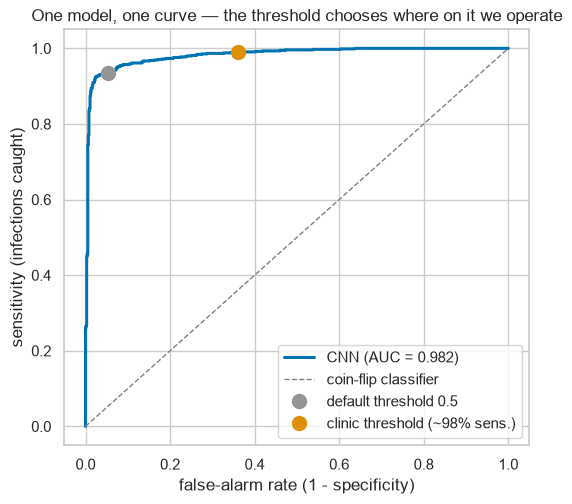

In [18]:
# The ROC curve on the test set, with BOTH operating points marked.
fpr_test, tpr_test, thresholds_test = roc_curve(y_test, test_probs)
auc = roc_auc_score(y_test, test_probs)   # area under the curve: 1.0 = perfect, 0.5 = coin flip

fig, ax = plt.subplots(figsize=(6, 5.4))
ax.plot(fpr_test, tpr_test, color="#0173B2", linewidth=2.2,
        label="CNN (AUC = " + str(round(float(auc), 3)) + ")")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1, label="coin-flip classifier")

# Each operating point is (false-alarm rate, sensitivity) at one threshold.
ax.plot(1 - specificity, sensitivity, "o", color="#949494", markersize=10,
        label="default threshold 0.5")
ax.plot(1 - specificity_clinic, sensitivity_clinic, "o", color="#DE8F05", markersize=10,
        label="clinic threshold (~98% sens.)")

ax.set_xlabel("false-alarm rate (1 - specificity)")
ax.set_ylabel("sensitivity (infections caught)")
ax.set_title("One model, one curve — the threshold chooses where on it we operate")
ax.legend(loc="lower right")
plt.show()

**Reading the evaluation.** The story in three rows:

- The CNN (94.2%) crushes the baseline (66.3%) — deep learning earned its complexity, and the AUC of **0.982** says the underlying score separates the classes very well.
- But at the default threshold the CNN missed **48 of 750 infections**. As a lab test, 93.6% sensitivity is a screening tool that sends 1 in 16 infected patients home — unacceptable.
- At the clinic threshold (0.044, chosen on validation data), we miss only **7 of 750** (99.1% sensitivity). The bill: specificity drops to 63.9%, i.e. **271 of 750 healthy cells** get flagged for human review. The flip side is what makes screening work: when this model says *clean*, it is right **479 times out of 486 (98.6%)**.

Is that trade worth it? With this small network, honestly, only just — flagging a third of healthy cells is a lot of re-checking. This is exactly what more data and more epochs would buy: a sharper ROC corner, meaning much higher specificity at the same 98%+ sensitivity (the full dataset gets this architecture to ~97–98% accuracy). The *protocol* — sensitivity first, threshold from validation data, cost stated explicitly — is what carries over to the bigger model unchanged.

## 6. Be your own reviewer

Any reviewer of a diagnostics paper asks the same question: *show me the failures.* The most
informative failures are the **false negatives** — the infections we still miss even at the
clinic threshold — sorted by how confidently wrong the model was.

missed infections at the clinic threshold: 7


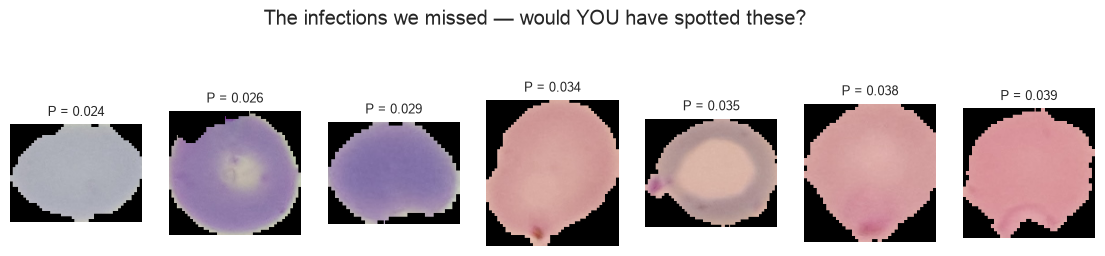

In [19]:
# Find the test-set positions of every false negative at the clinic threshold.
fn_positions = []
for i in range(len(y_test)):
    if y_test[i] == 1 and clinic_predictions[i] == 0:
        fn_positions.append(i)
print("missed infections at the clinic threshold:", len(fn_positions))

# Sort them by the model's P(parasitized), smallest first = most confidently wrong.
fn_probs = test_probs[fn_positions]
order = np.argsort(fn_probs)     # argsort = positions that would sort the array (Module 01)

n_show = min(8, len(fn_positions))
fig, axes = plt.subplots(1, n_show, figsize=(2 * n_show, 2.7))
for k in range(n_show):
    pos = fn_positions[order[k]]           # position within the test set
    original_row = int(test_idx[pos])      # row in the full dataset -> the original photo
    axes[k].imshow(cells[original_row]["image"])
    axes[k].set_title("P = " + str(round(float(test_probs[pos]), 3)), fontsize=9)
    axes[k].axis("off")
fig.suptitle("The infections we missed — would YOU have spotted these?", y=1.1)
plt.show()

false alarms at the clinic threshold: 271


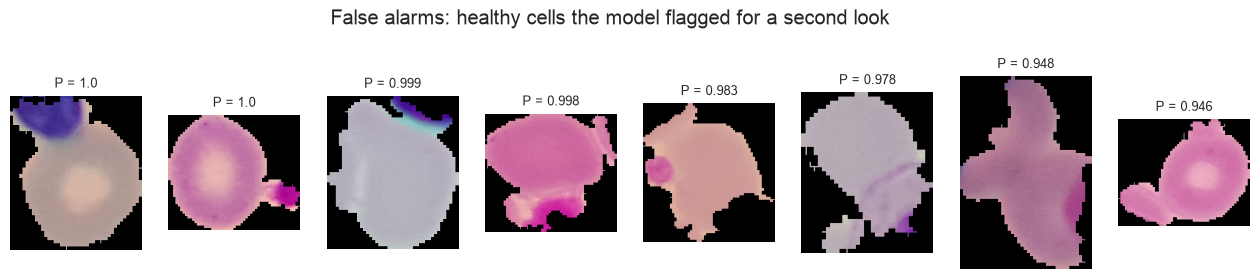

In [20]:
# And the loudest false alarms: healthy cells the model was most sure were infected.
fp_positions = []
for i in range(len(y_test)):
    if y_test[i] == 0 and clinic_predictions[i] == 1:
        fp_positions.append(i)
print("false alarms at the clinic threshold:", len(fp_positions))

fp_probs = test_probs[fp_positions]
order_fp = np.argsort(fp_probs)[::-1]    # [::-1] reverses the order: biggest P first

fig, axes = plt.subplots(1, 8, figsize=(16, 2.7))
for k in range(8):
    pos = fp_positions[order_fp[k]]
    original_row = int(test_idx[pos])
    axes[k].imshow(cells[original_row]["image"])
    axes[k].set_title("P = " + str(round(float(test_probs[pos]), 3)), fontsize=9)
    axes[k].axis("off")
fig.suptitle("False alarms: healthy cells the model flagged for a second look", y=1.1)
plt.show()

**A biologist reads the failures.** Look closely at the two grids — the patterns are not random:

- **Missed infections, type 1: the parasite hugs the cropped edge.** Several false negatives show a single tiny stained dot at the very rim of the cell — partially cut off by the segmentation, and shrunk to a couple of pixels by our 64×64 resize. A higher-resolution input might recover these.
- **Missed infections, type 2: the whole cell stained deep purple.** When the entire cytoplasm takes up stain, the parasite no longer stands out by local contrast — the very feature the filters seem to rely on.
- **Missed infections, type 3: nothing visible at all.** At least one missed "parasitized" cell looks clean even to a careful human eye. Possible label error, or a parasite lost to focus/resizing — a reminder that our ground truth is expert opinion, not sequencing.
- **False alarms: things that look like parasites.** The flagged healthy cells carry stained debris, platelet-sized magenta blobs stuck to the membrane, or fragments of a *neighboring* cell caught in the crop — exactly the objects that fool novice microscopists too. The model fails the way a first-year student fails, which is oddly reassuring.

### Honest limitations

Before anyone gets excited, the reviewer in us writes this paragraph:

- **One hospital, one staining protocol.** Every image comes from Chittagong Medical College
  Hospital. Stain color and lighting vary between labs, and our model may have quietly learned
  *this lab's* color balance. A different clinic's smears would need re-validation (and likely
  fine-tuning).
- **Single cells, not slides.** The hard step of finding and segmenting individual cells in a
  full smear photo was done for us. A deployable tool needs that front end too, plus handling
  of white blood cells, platelets, and debris that this dataset filtered out.
- **Labels taken on faith.** Expert readers labeled the cells; experts are occasionally wrong,
  especially on early ring stages — some of our "errors" may be label errors.
- **A subsample, a small network, few epochs.** We used 8,500 of 27,558 images and stopped at
  6 epochs to fit a laptop budget; the full dataset and longer training reach ~97–98% accuracy.
- **No clinical validation.** This is a research prototype. Between here and a clinic sit
  prospective trials, regulatory review, and calibration on the target population — the same
  distance as between a promising Western blot and an approved diagnostic.

## 7. Write it up

A whole investigation, condensed to a paper-style abstract — if it doesn't fit in ~150 words,
we haven't found the story yet.

---

**Automated screening of Plasmodium-parasitized red blood cells from thin-smear photomicrographs**

**Background.** Malaria microscopy is the diagnostic gold standard but requires scarce trained
readers. We asked whether a small convolutional neural network could flag parasitized red blood
cells for human review.

**Methods.** From the NIH malaria dataset (27,558 expert-labeled single-cell images from
Giemsa-stained thin smears, Chittagong Medical College Hospital, Bangladesh) we drew a
stratified subsample of 6,000 training, 1,000 validation, and 1,500 test cells (seed 42). We
compared logistic regression on raw 32×32 pixels against a three-block CNN on 64×64 color
images (6 epochs, Adam, binary cross-entropy). A screening threshold targeting 98% sensitivity
was selected on validation data only; the test set was used once.

**Results.** The pixel baseline reached 66.3% test accuracy, limited by the parasite's
variable position. The CNN reached 94.2% accuracy (sensitivity 93.6%, specificity 94.8%,
AUC 0.982). At the screening threshold, sensitivity was 99.1% (7/750 infections missed) at
63.9% specificity (271/750 healthy cells flagged); a "clean" call was correct 98.6% of the
time. Review of residual false negatives implicated edge-cropped parasites, uniformly
hyper-stained cells, and possible label error.

**Limitations.** Single-site data (one hospital, one staining protocol), pre-segmented single
cells rather than whole slides, and no clinical validation. Results support feasibility of
CNN-assisted screening, not deployment.

---

### Now write yours

Fill in the template below from *your* attempt (your numbers will differ if any choice
differed — that's the interesting part):

> **Background.** Malaria diagnosis requires ________, which is scarce because ________.
> We asked whether ________.
> **Methods.** From the NIH malaria dataset (27,558 single-cell images) we sampled ________
> images, split ________ / ________ / ________ (stratified, seed ________). We compared
> ________ against ________, and selected a screening threshold on ________ data targeting
> ________% sensitivity.
> **Results.** The baseline reached ________% test accuracy. The CNN reached ________%
> (sensitivity ________%, specificity ________%). At the screening threshold, sensitivity was
> ________% and specificity ________%, i.e. ________ missed infections and ________ false
> alarms out of ________ test cells.
> **Limitations.** ________.

**Where to go next, if this project hooked you:** train on all 27,558 images (or on the GPU via
`.to("mps")`, Module 10); add data augmentation (random flips/rotations — cells have no
preferred orientation); try transfer learning from a pretrained network; or find a second
malaria cell dataset and test *cross-site* generalization — the real unsolved problem here.